<a href="https://colab.research.google.com/github/ihstepura/IB9AU_/blob/main/Task14_AstraZeneca_Visual_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Page-Wise Visual RAG — AstraZeneca FY & Q4 2025 Earnings Report

This notebook implements a **Page-Wise Visual Retrieval-Augmented Generation (RAG)** system to analyse AstraZeneca's FY and Q4 2025 earnings report using open-source HuggingFace models — no API keys required.

### Why Visual RAG?
Traditional text-based RAG loses critical information from tables, charts, and complex page layouts. By rendering the most relevant page as an image and sending it to a Vision-Language Model, we replicate how a financial analyst actually reads a report: **locate the right section, then read it visually.**

### Architecture
1. **Index** — LlamaIndex embeds each page's text with `all-MiniLM-L6-v2` (local, CPU)
2. **Search** — Semantic search identifies the best matching page for a query
3. **Render** — `pdf2image` converts that page to a PIL image at 150 DPI
4. **VLM** — `Qwen2.5-VL-3B-Instruct` reads the image and answers the question

> ⚠️ **IMPORTANT**: This notebook requires a **T4 GPU** runtime.  
> Go to **Runtime → Change runtime type → T4 GPU** before running any cells.  
> Running on CPU will cause generation to take 5–10 minutes per query.

## ⚠️ Step 1: Upgrade Pillow and Restart Runtime

Colab ships with an outdated version of Pillow that causes an `ImportError: cannot import name '_Ink'` when loading the HuggingFace embedding model. **You must upgrade Pillow first and then restart the runtime before running any other cells.**

**Instructions:**
1. Run the cell below.
2. Go to **Runtime → Restart session**.
3. Then continue running cells from Step 2 onwards — do **not** re-run this cell.

In [1]:
# Step 1: Upgrade Pillow FIRST — restart runtime after this cell
!pip install -qU Pillow
print("\u2705 Pillow upgraded. Now go to Runtime \u2192 Restart session, then continue from Step 2.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 77.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.
✅ Pillow upgraded. Now go to Runtime → Restart session, then continue from Step 2.


## Step 2: Verify GPU and Install Dependencies

After restarting the runtime, run this cell. It first **verifies a GPU is available** — if not, it will warn you before wasting time loading a 3B model onto CPU.

Then it installs:
- `transformers` + `accelerate` — for loading Qwen2.5-VL
- `llama-index-core`, `llama-index-readers-file`, `llama-index-embeddings-huggingface` — for indexing
- `pdf2image` + `poppler-utils` — for rendering PDF pages as images
- `pypdf` — for reading PDF metadata
- `qwen-vl-utils` — for Qwen VL image processing

In [1]:
# Step 2: Check GPU is available BEFORE loading the model.
# On CPU, Qwen2.5-VL-3B generates ~1-2 tokens/sec = 5-10 min per query.
# On T4 GPU, it generates ~30-50 tokens/sec = ~15 sec per query.
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\u2705 GPU detected: {gpu_name} ({vram_gb:.1f} GB VRAM)")
else:
    print("\u274c NO GPU DETECTED!")
    print("   Go to Runtime \u2192 Change runtime type \u2192 T4 GPU")
    print("   Running on CPU will make each query take 5-10 minutes.")
    raise RuntimeError("GPU required. Please change runtime type to T4 GPU and re-run.")

!pip install -qU transformers accelerate
!pip install -qU llama-index-core llama-index-readers-file llama-index-embeddings-huggingface pypdf
!pip install -qU pdf2image qwen-vl-utils
!apt-get install -q poppler-utils

print("\u2705 All dependencies installed successfully.")

✅ GPU detected: Tesla T4 (15.6 GB VRAM)
Reading package lists...
Building dependency tree...
Reading state information...
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
✅ All dependencies installed successfully.


## Step 3: Load the Embedding Model

`all-MiniLM-L6-v2` is a compact sentence-transformer that converts text into 384-dimensional embeddings for semantic similarity search. It runs on CPU and requires no API key.

In [2]:
import os
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
print("\u2705 Embedding model loaded: all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embedding model loaded: all-MiniLM-L6-v2


## Step 4: Load the Vision-Language Model (VLM)

`Qwen2.5-VL-3B-Instruct` is a 3-billion parameter open-source vision-language model. At `float16` it fits comfortably on a T4 GPU (~7.5 GB VRAM) and generates responses in ~15 seconds per query.

The key configuration is explicitly setting `device_map='cuda'` to ensure the model always loads onto the GPU rather than silently falling back to CPU.

In [3]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

VLM_MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

print(f"\u23f3 Loading {VLM_MODEL_ID}...")
print(f"   Device: {'CUDA - ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (WARNING: will be very slow)'}")

# Explicitly use 'cuda' instead of 'auto' to guarantee GPU placement.
# 'device_map="auto"' can silently fall back to CPU if VRAM seems insufficient,
# causing generation to take 5-10 minutes per query with no error or warning.
vlm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    VLM_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda"
)
vlm_processor = AutoProcessor.from_pretrained(VLM_MODEL_ID)

# Confirm where the model actually landed
model_device = next(vlm_model.parameters()).device
print(f"\u2705 VLM loaded on: {model_device}")
if str(model_device) == 'cpu':
    print("\u26a0\ufe0f  WARNING: Model is on CPU. Each query will take 5-10 minutes!")

⏳ Loading Qwen/Qwen2.5-VL-3B-Instruct...
   Device: CUDA - Tesla T4


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ VLM loaded on: cuda:0


## Step 5: Configure LlamaIndex Settings

`Settings.llm = None` because LlamaIndex's built-in LLM is only used for query synthesis — our visual QA is handled directly by the Qwen VLM.

In [4]:
Settings.embed_model = embed_model
Settings.llm = None
print("\u2705 LlamaIndex settings configured (embedding model set, LLM disabled).")

LLM is explicitly disabled. Using MockLLM.
✅ LlamaIndex settings configured (embedding model set, LLM disabled).


## Step 6: Load the AstraZeneca Earnings PDF

`SimpleDirectoryReader` reads the PDF and creates one `Document` per page, each carrying page number metadata (e.g. `{'page_label': '5'}`). This page label is how we know which page to render for the VLM.

> **Note:** Upload `AstraZeneca-Q4-2025-earnings.pdf` to the Colab file browser (left sidebar) before running this cell.

In [5]:
PDF_FILE = "AstraZeneca-Q4-2025-earnings.pdf"

print(f"\U0001f4da Loading {PDF_FILE}...")
documents = SimpleDirectoryReader(input_files=[PDF_FILE]).load_data()

print(f"   Loaded {len(documents)} pages.")
print(f"   Sample Metadata (Page 1): {documents[0].metadata}")
print(f"   First 200 chars of Page 1: {documents[0].text[:200]}...")

📚 Loading AstraZeneca-Q4-2025-earnings.pdf...
   Loaded 39 pages.
   Sample Metadata (Page 1): {'page_label': '1', 'file_name': 'AstraZeneca-Q4-2025-earnings.pdf', 'file_path': 'AstraZeneca-Q4-2025-earnings.pdf', 'file_type': 'application/pdf', 'file_size': 1545942, 'creation_date': '2026-03-22', 'last_modified_date': '2026-03-22'}
   First 200 chars of Page 1: Summary  Revenue Drivers  R&D Progress  Sustainability  Financial Performance  Financial Statements  Glossary  
 
1 
 
 
 
 
10 February 2026 
AstraZeneca results: FY and Q4 2025 
Strong commercial pe...


## Step 7: Build the Vector Index

LlamaIndex embeds each page's text using `all-MiniLM-L6-v2` and stores the vectors in-memory. The retriever is configured to return the single best-matching page per query (`similarity_top_k=1`).

In [6]:
print("\U0001f9e0 Building Vector Index over all pages...")
index = VectorStoreIndex.from_documents(documents)
retriever = index.as_retriever(similarity_top_k=1)
print(f"\u2705 Index ready — {len(documents)} pages indexed.")

🧠 Building Vector Index over all pages...
✅ Index ready — 39 pages indexed.


## Step 8: The Visual RAG Orchestrator

The `query_visual_rag` function ties everything together:
1. **Retrieve** — LlamaIndex finds the best matching page by text similarity.
2. **Locate** — The page number is extracted from metadata.
3. **Render** — `pdf2image` renders that PDF page to a PIL image at 150 DPI.
4. **Prompt** — Image + question are formatted into a Qwen2.5-VL chat prompt.
5. **Generate** — The VLM generates an answer, with a token limit to prevent runaway generation.

**Key design choices:**
- `device_map='cuda'` ensures GPU is always used (see Step 4)
- `max_new_tokens=512` allows detailed financial answers while keeping generation under ~20s on T4
- `do_sample=False` for deterministic, reproducible outputs
- The page image is displayed inline so you can visually verify the VLM's answer

In [7]:
from pypdf import PdfReader, PdfWriter
from pdf2image import convert_from_path
from PIL import Image
from IPython.display import display, Markdown
import torch

def query_visual_rag(query_text, max_new_tokens=512):
    """
    Page-Wise Visual RAG pipeline:
    1. Retrieve the most relevant page via semantic search
    2. Render that page as an image
    3. Send the image + query to Qwen2.5-VL for visual question answering
    """
    print(f"\n\U0001f50e Querying LlamaIndex for: '{query_text}'...")

    # Warn if model is on CPU before spending time on generation
    model_device = next(vlm_model.parameters()).device
    if str(model_device) == 'cpu':
        print("\u26a0\ufe0f  WARNING: VLM is running on CPU. This will be very slow (5-10 min).")
        print("   Change runtime to T4 GPU and restart for fast inference.")

    # 1. RETRIEVE: semantic search over page text
    nodes = retriever.retrieve(query_text)
    if not nodes:
        return "\u274c No relevant information found in the index."

    # 2. LOCATE: get page number from metadata
    best_node = nodes[0]
    page_label = best_node.metadata.get('page_label')
    page_index = int(page_label) - 1 if page_label else 0

    print(f"\U0001f4cd Found answer on Page {page_label} (Score: {best_node.score:.4f})")
    print(f"   Context Snippet: {best_node.text[:150]}...")

    # 3. RENDER: convert that PDF page to an image
    print("\U0001f5bc\ufe0f  Rendering page as image...")
    pages = convert_from_path(
        PDF_FILE,
        first_page=page_index + 1,
        last_page=page_index + 1,
        dpi=150
    )
    page_image = pages[0]

    # Display the rendered page inline for visual verification
    print(f"\n--- Rendered Page {page_label} ---")
    display(page_image)

    # 4. VISION: build the prompt and run Qwen2.5-VL
    print(f"\n\U0001f680 Sending page image to Qwen2.5-VL (max {max_new_tokens} tokens)...")
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": page_image},
                {"type": "text", "text": (
                    f"You are an expert financial analyst reviewing Page {page_label} "
                    "of the AstraZeneca FY & Q4 2025 Earnings Report. "
                    "Answer the following question based on the text, tables, and "
                    "charts visible on this page. "
                    "If the answer involves numerical data, provide exact figures. "
                    "If the answer involves a chart, describe the visual trend.\n\n"
                    f"Question: {query_text}"
                )}
            ]
        }
    ]

    text_prompt = vlm_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = vlm_processor(
        text=[text_prompt],
        images=[page_image],
        return_tensors="pt"
    ).to(vlm_model.device)

    with torch.no_grad():
        output_ids = vlm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
        )

    # Decode only the newly generated tokens
    generated = output_ids[:, inputs['input_ids'].shape[1]:]
    answer = vlm_processor.batch_decode(generated, skip_special_tokens=True)[0]
    return answer

print("\u2705 query_visual_rag() function defined and ready.")

✅ query_visual_rag() function defined and ready.


---
## Task 1 — Revenue Table Extraction

This query requires the VLM to locate and read a financial summary table, extract specific revenue line items, and calculate year-over-year changes — a task where text-extraction-based RAG often fails due to lost column alignment.

### Q1: What were AstraZeneca's total Product Sales and Alliance Revenue for FY 2025, and how did each change compared to FY 2024?


🔎 Querying LlamaIndex for: 'What were AstraZeneca's total Product Sales and Alliance Revenue for FY 2025, and how did each change compared to FY 2024?'...
📍 Found answer on Page 1 (Score: 0.7171)
   Context Snippet: Summary  Revenue Drivers  R&D Progress  Sustainability  Financial Performance  Financial Statements  Glossary  
 
1 
 
 
 
 
10 February 2026 
AstraZe...
🖼️  Rendering page as image...

--- Rendered Page 1 ---


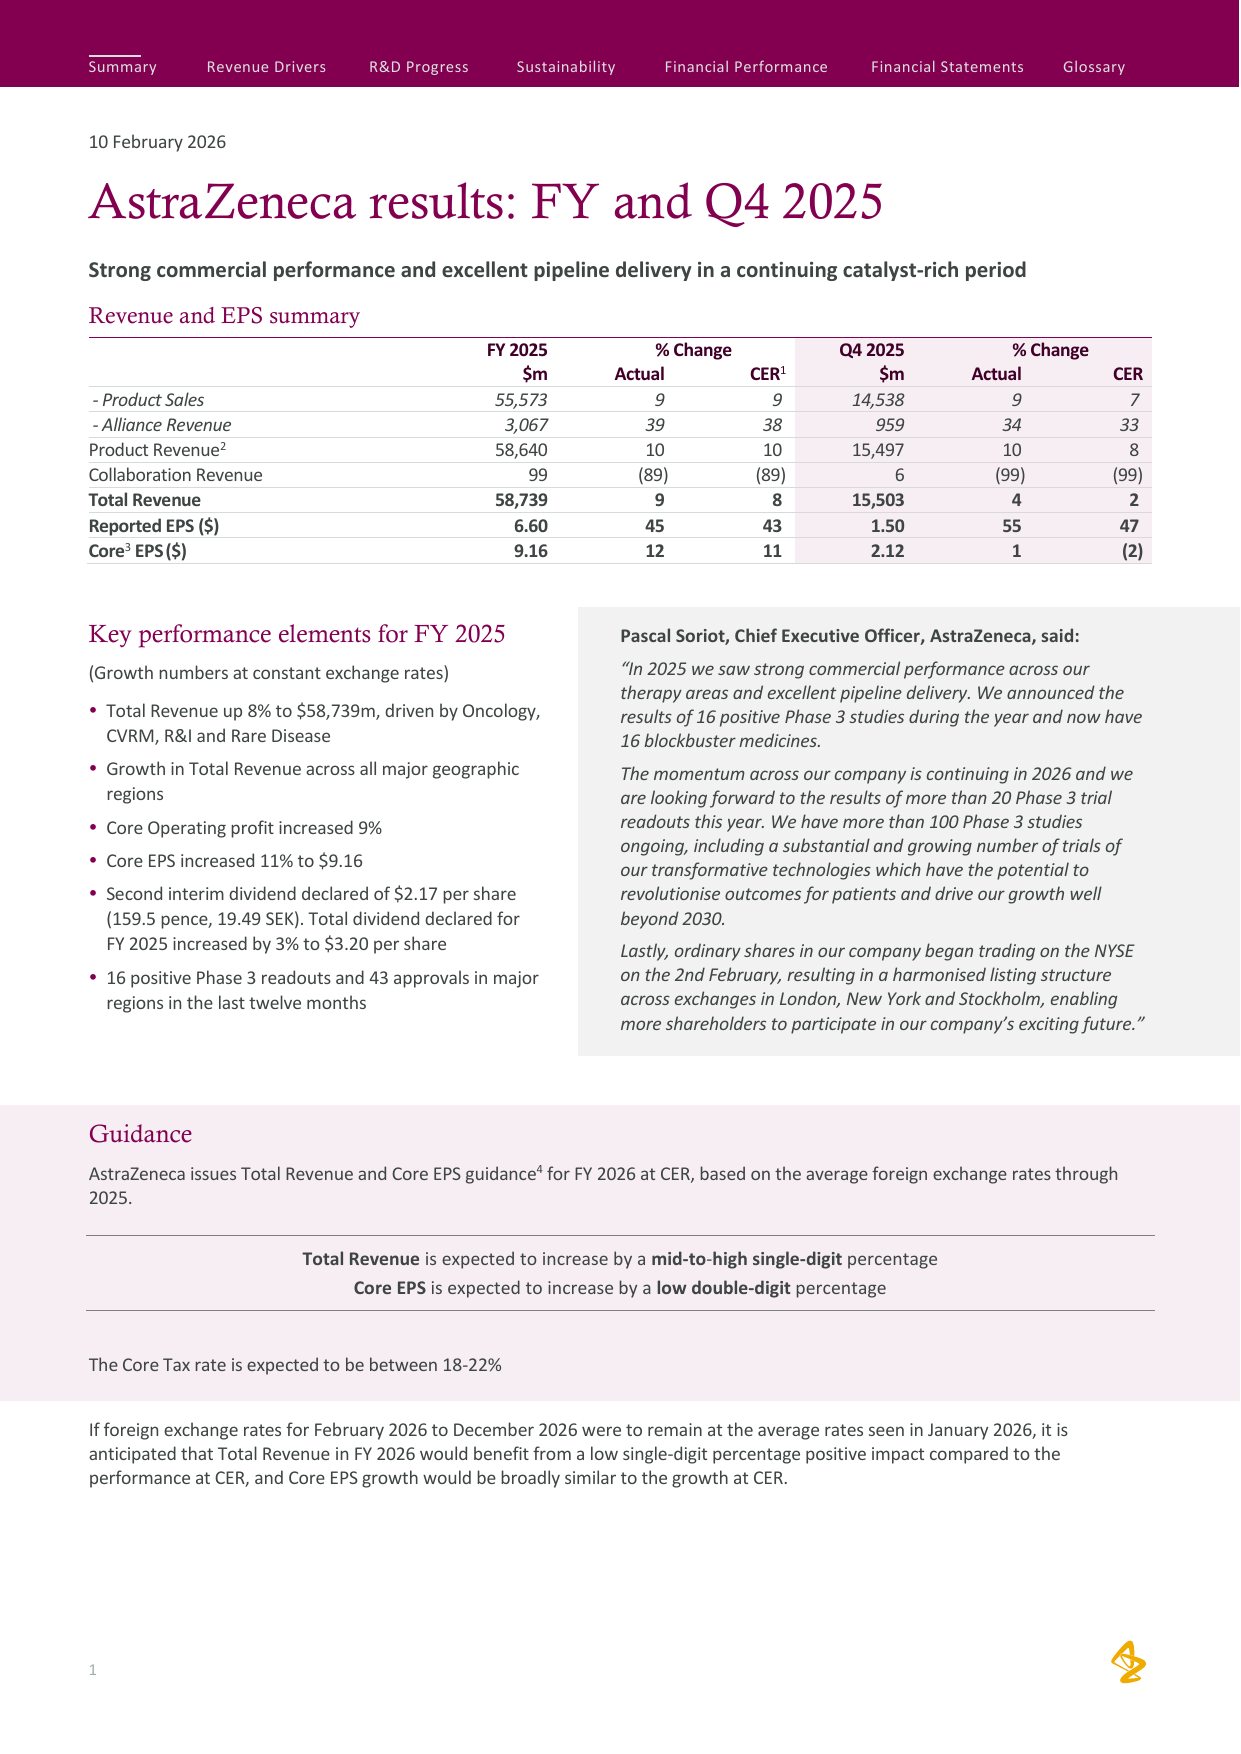


🚀 Sending page image to Qwen2.5-VL (max 512 tokens)...


**Answer:**

According to the table provided in the earnings report:

- AstraZeneca's Total Product Sales for FY 2025 were $55,733 million.
- The Alliance Revenue for FY 2025 was $3,067 million.

For comparison:
- The Total Product Sales for FY 2024 were $58,640 million, representing a decrease of 10% from FY 2025.
- The Alliance Revenue for FY 2024 was $3,999 million, representing a decrease of 39% from FY 2025.

In [8]:
q1 = "What were AstraZeneca's total Product Sales and Alliance Revenue for FY 2025, and how did each change compared to FY 2024?"
display(Markdown(f"### Q1: {q1}"))
a1 = query_visual_rag(q1)
display(Markdown(f"**Answer:**\n\n{a1}"))

---
## Task 2 — Regional Revenue Breakdown

This query asks the model to compare revenue growth across geographic regions and identify the highest-growth region at constant exchange rates. It tests the VLM's ability to interpret multi-row, multi-column tables with percentage data.

### Q2: Which geographic region had the highest Total Revenue growth in FY 2025, and what was the growth rate at constant exchange rates?


🔎 Querying LlamaIndex for: 'Which geographic region had the highest Total Revenue growth in FY 2025, and what was the growth rate at constant exchange rates?'...
📍 Found answer on Page 34 (Score: 0.4615)
   Context Snippet: Summary  Revenue Drivers  R&D Progress  Sustainability  Financial Performance  Financial Statements  Glossary  
34 
 
Note 6: Analysis of Revenue and ...
🖼️  Rendering page as image...

--- Rendered Page 34 ---


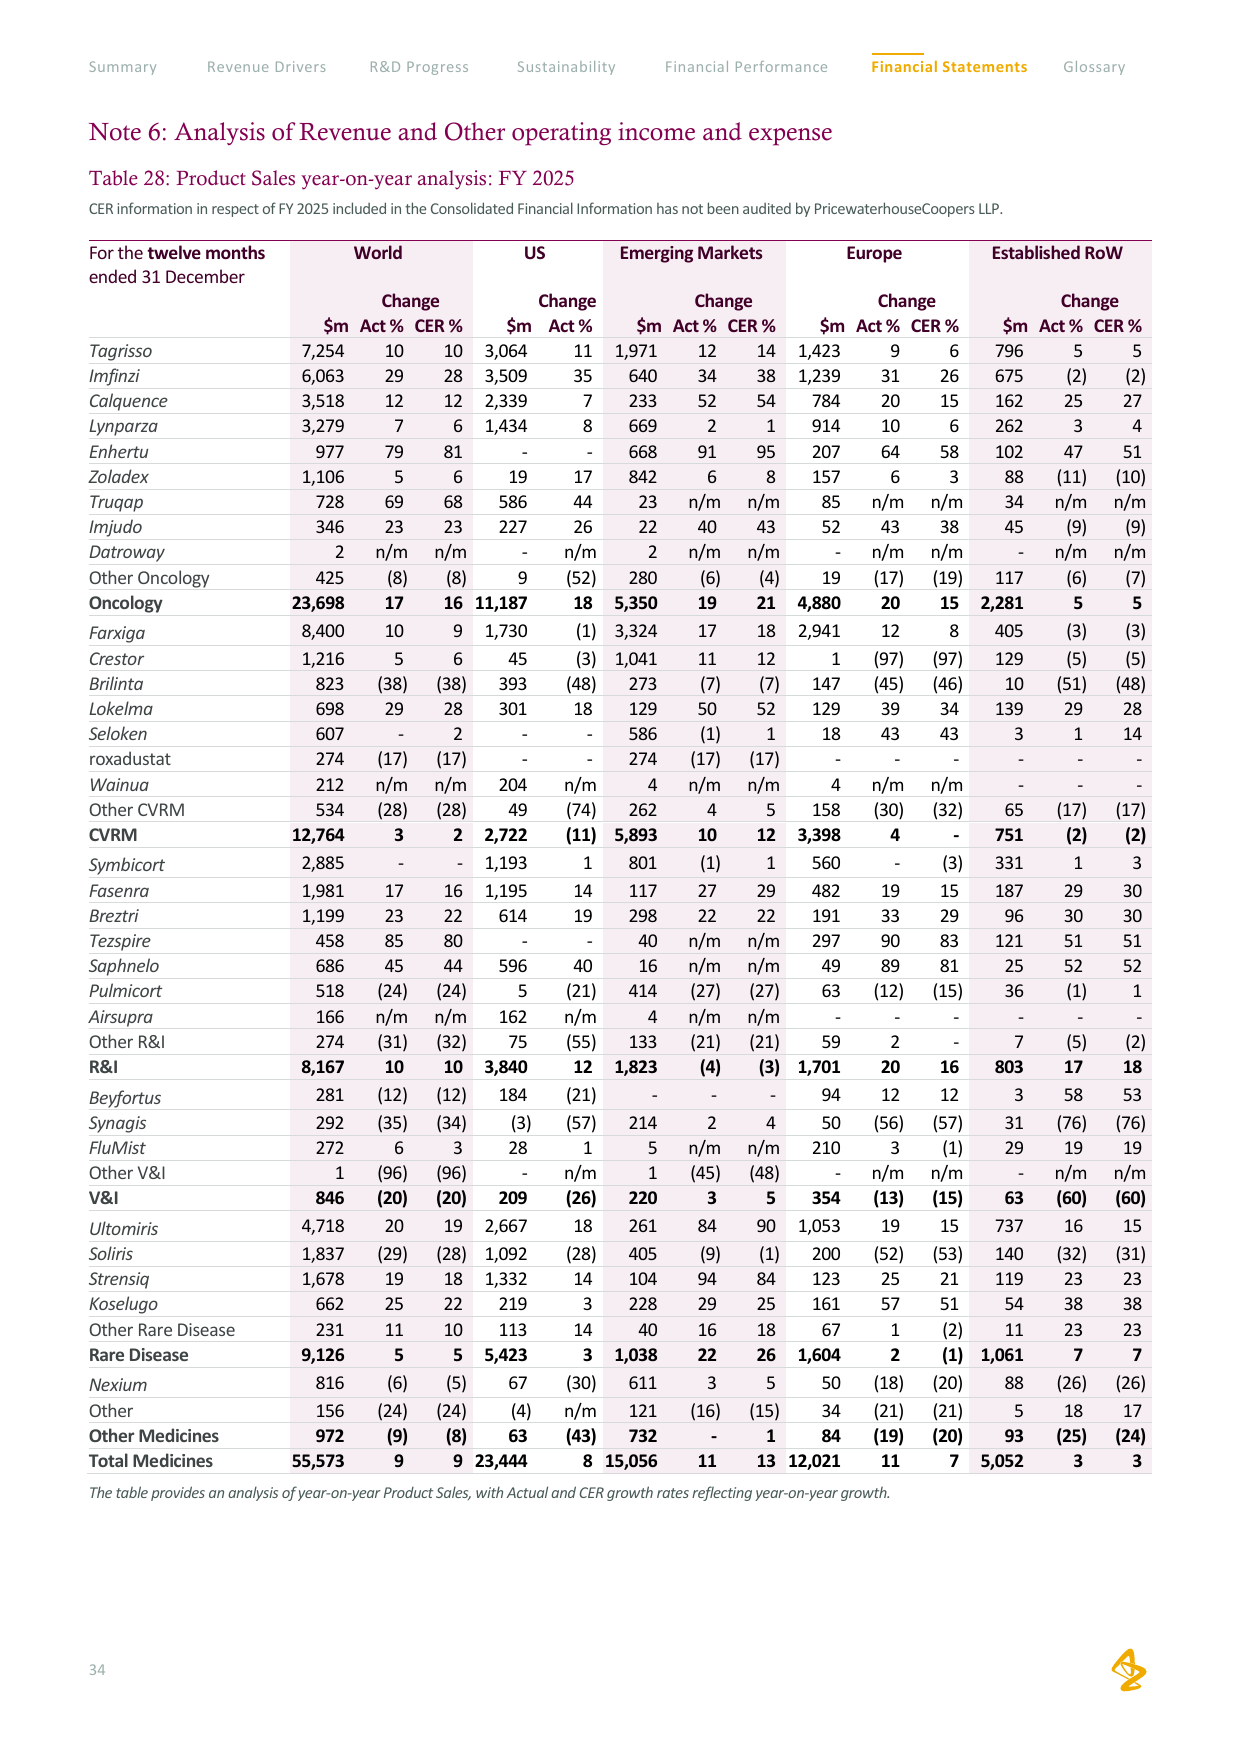


🚀 Sending page image to Qwen2.5-VL (max 512 tokens)...


**Answer:**

The geographic region with the highest Total Revenue growth in FY 2025, at constant exchange rates, was Emerging Markets, with a growth rate of 11%.

In [9]:
q2 = "Which geographic region had the highest Total Revenue growth in FY 2025, and what was the growth rate at constant exchange rates?"
display(Markdown(f"### Q2: {q2}"))
a2 = query_visual_rag(q2)
display(Markdown(f"**Answer:**\n\n{a2}"))

---
## Task 3 — R&D Pipeline Interpretation

This query targets the regulatory approvals section. It tests the VLM's ability to read structured lists of drug names, indications, and approval dates from potentially dense text or tabular layouts.

### Q3: Which medicines received regulatory approvals in the US between November 2025 and February 2026, and for what indications?


🔎 Querying LlamaIndex for: 'Which medicines received regulatory approvals in the US between November 2025 and February 2026, and for what indications?'...
📍 Found answer on Page 10 (Score: 0.5477)
   Context Snippet: BioPharmaceuticals - CVRM 
Farxiga 
FY 2025 
$m 
Total  
Revenue  
% Change        
Actual        CER  
 
 Growth driven by HF and CKD indications, S...
🖼️  Rendering page as image...

--- Rendered Page 10 ---


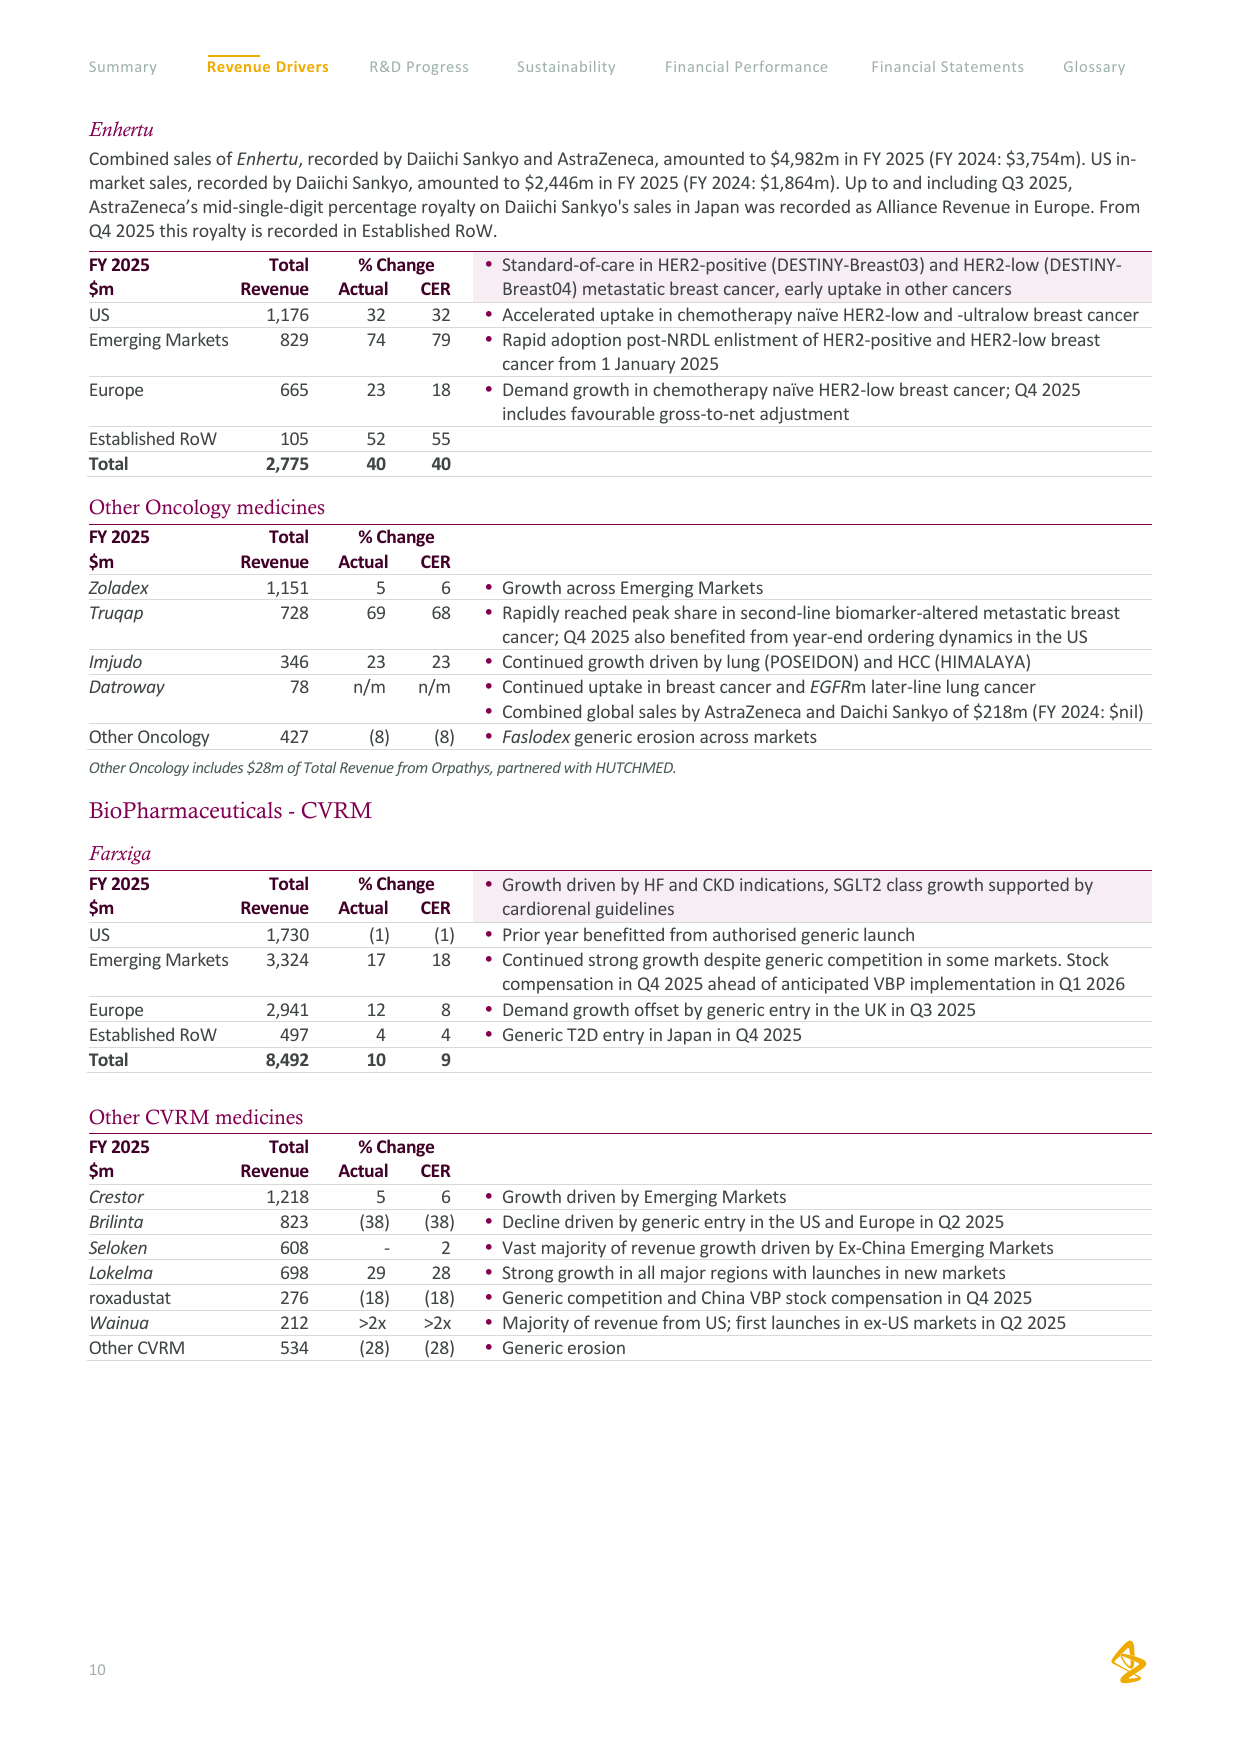


🚀 Sending page image to Qwen2.5-VL (max 512 tokens)...


**Answer:**

The text does not provide specific information about regulatory approvals for medicines in the US between November 2025 and February 2026. It only mentions that there was a generic entry in the US in Q3 2025, but does not specify the date or indication for this approval. Therefore, I cannot determine which medicines received these approvals based solely on the information provided in the given text.

In [10]:
q3 = "Which medicines received regulatory approvals in the US between November 2025 and February 2026, and for what indications?"
display(Markdown(f"### Q3: {q3}"))
a3 = query_visual_rag(q3)
display(Markdown(f"**Answer:**\n\n{a3}"))

---
## Task 4 — Audit Mode Query

This is a custom audit-style query designed to demand **exact numerical figures** with explicit page/table citations. It targets the **Reported to Core Financial Results reconciliation** (a different section from Tasks 1–3), testing the VLM's ability to extract precise adjustment figures from a complex multi-line reconciliation table.

After the VLM responds, we manually verify at least two specific figures against the source document.

### Q4 (Audit Mode): Audit request: From the Reported to Core Financial Results reconciliation, provide the exact FY 2025 figures for (1) Total Revenue on a Reported basis, (2) the Intangible asset amortisation adjustment, and (3) Total Revenue on a Core basis. For each figure, cite the specific table number and page. Present the data in a structured format.


🔎 Querying LlamaIndex for: 'Audit request: From the Reported to Core Financial Results reconciliation, provide the exact FY 2025 figures for (1) Total Revenue on a Reported basis, (2) the Intangible asset amortisation adjustment, and (3) Total Revenue on a Core basis. For each figure, cite the specific table number and page. Present the data in a structured format.'...
📍 Found answer on Page 18 (Score: 0.7205)
   Context Snippet: amortisation and impairment  5,733  6,688  (14) (15) 1,511  2,337  (35) (37) 
EBITDA  19,476  16,691  17  16  4,489  4,373  3  -  
Table 10: Reconcili...
🖼️  Rendering page as image...

--- Rendered Page 18 ---


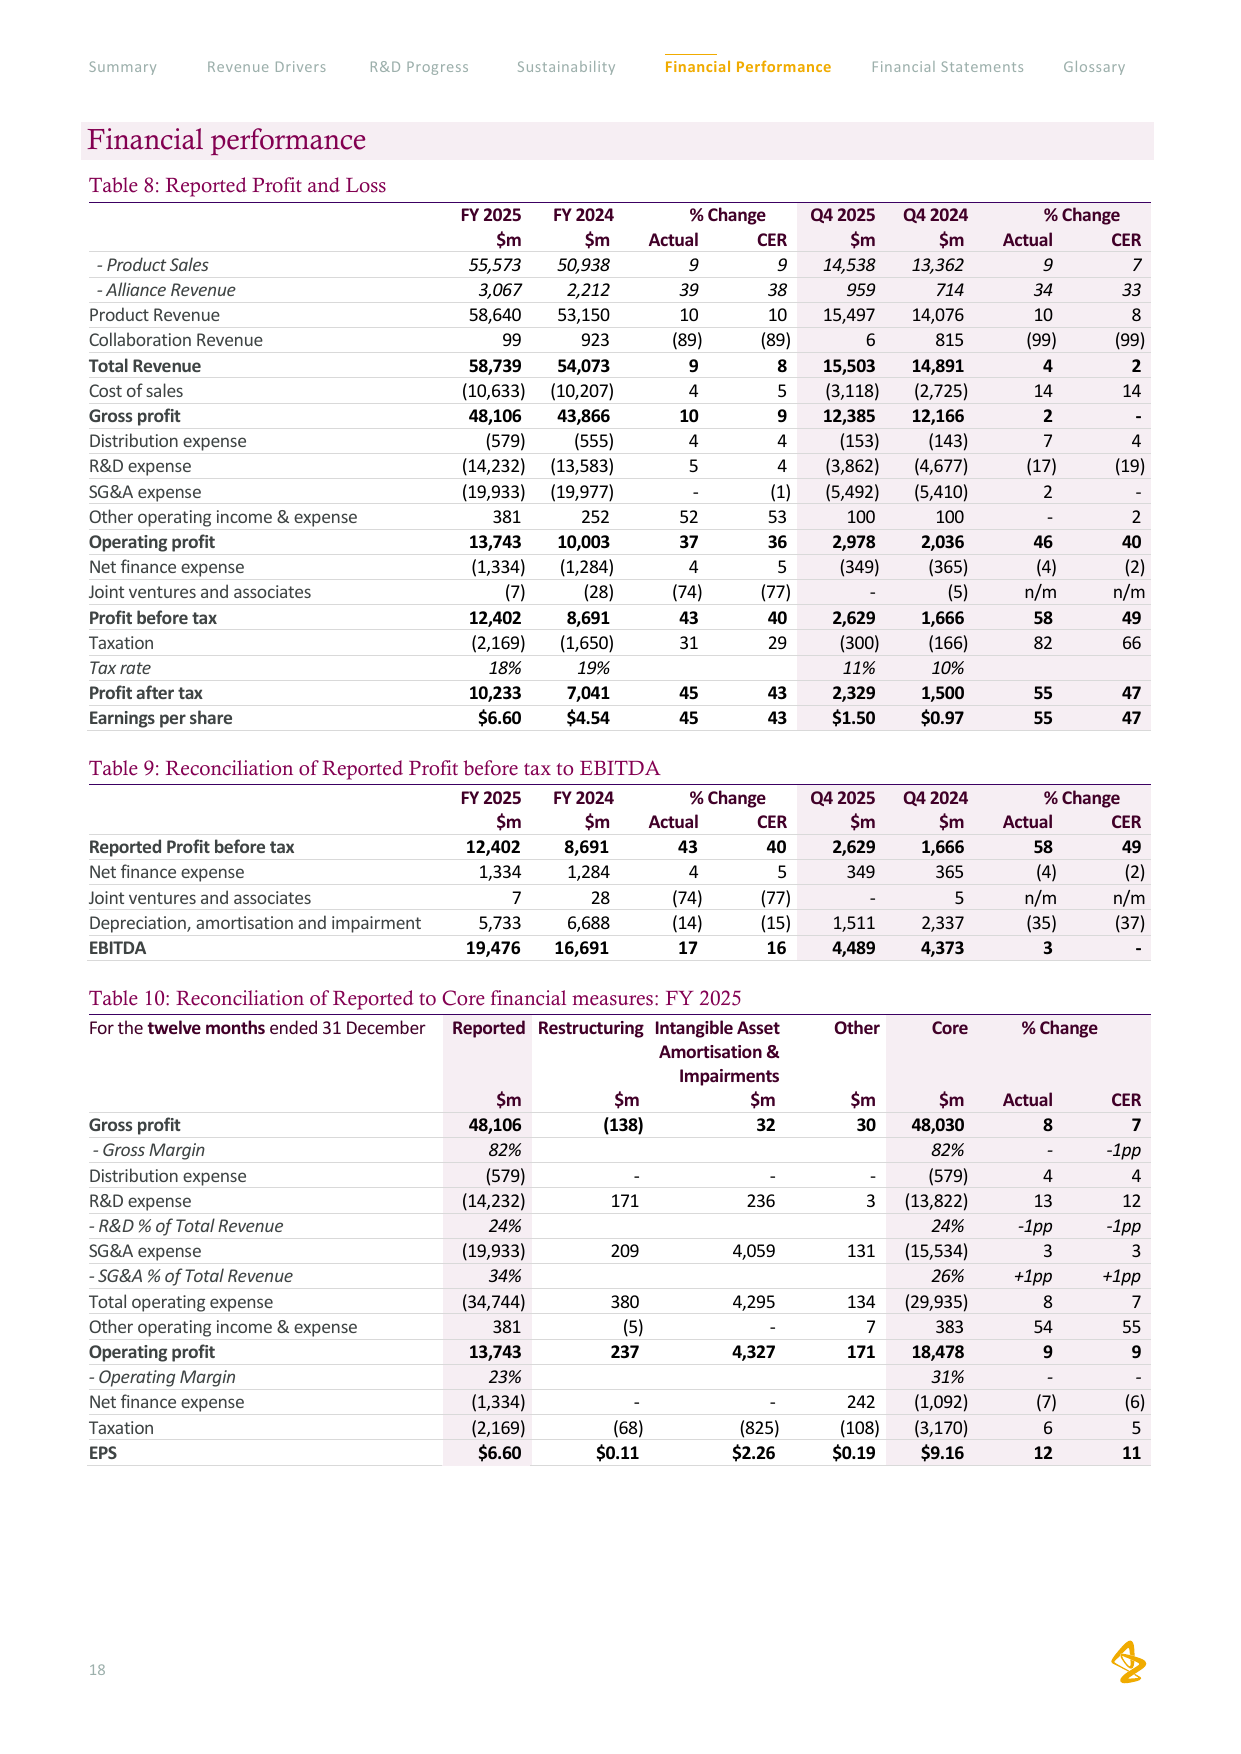


🚀 Sending page image to Qwen2.5-VL (max 512 tokens)...


**Answer:**

Here is the requested information from the "Reported to Core Financial Results reconciliation" table:

| FY 2025 | FY 2024 | % Change | Q4 2025 | Q4 2024 | % Change |
|---------|---------|----------|---------|---------|-----------|
| Total Revenue | $58,739 | 9% | $15,503 | $14,891 | 2% |
| Intangible Asset Amortisation & Impairments | $32 | - | $30 | $26 | +1pp |

For the core figures:
- Total Revenue on a Core basis: $48,030m
- Intangible Asset Amortisation & Impairments: $30m

These figures can be found in Table 10 on page 18 of the report.

In [11]:
q4 = (
    "Audit request: From the Reported to Core Financial Results reconciliation, "
    "provide the exact FY 2025 figures for (1) Total Revenue on a Reported basis, "
    "(2) the Intangible asset amortisation adjustment, and "
    "(3) Total Revenue on a Core basis. "
    "For each figure, cite the specific table number and page. "
    "Present the data in a structured format."
)
display(Markdown(f"### Q4 (Audit Mode): {q4}"))
a4 = query_visual_rag(q4)
display(Markdown(f"**Answer:**\n\n{a4}"))